# Brooklyn Community District Case Study

This notebook fetches a larger live Brooklyn sample into memory and uses it for exploratory analysis with notebook-native tables and simple charts.

Setup for local use:
- run `uv sync --extra science --group notebooks`
- select the project `.venv` / `nyc311` kernel in Jupyter or VS Code

The flow is deliberately path-free so someone can open it in Colab or a fresh notebook environment and start working immediately.

In [6]:
from collections import Counter
from pathlib import Path
import sys

from IPython.display import display

import nyc311

repo_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "examples").exists() and (candidate / "src").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.utils import brooklyn_borough_filter, brooklyn_socrata_config

records = nyc311.fetch_service_requests(
    filters=brooklyn_borough_filter(
        start_date="2025-01-01",
        end_date="2025-03-31",
    ),
    socrata_config=brooklyn_socrata_config(page_size=1000, max_pages=5),
)

len(records)

5000

,complaint_type,count
0,Illegal Parking,1117
1,HEAT/HOT WATER,582
2,Noise - Residential,509
3,Blocked Driveway,318
4,Street Condition,131
5,UNSANITARY CONDITION,128
6,Noise - Street/Sidewalk,125
7,Abandoned Vehicle,124
8,PLUMBING,113
9,Illegal Fireworks,105


,community_district,count
0,05 BROOKLYN,466
1,14 BROOKLYN,430
2,11 BROOKLYN,380
3,01 BROOKLYN,364
4,02 BROOKLYN,343
5,12 BROOKLYN,282
6,15 BROOKLYN,271
7,18 BROOKLYN,269
8,06 BROOKLYN,260
9,10 BROOKLYN,256


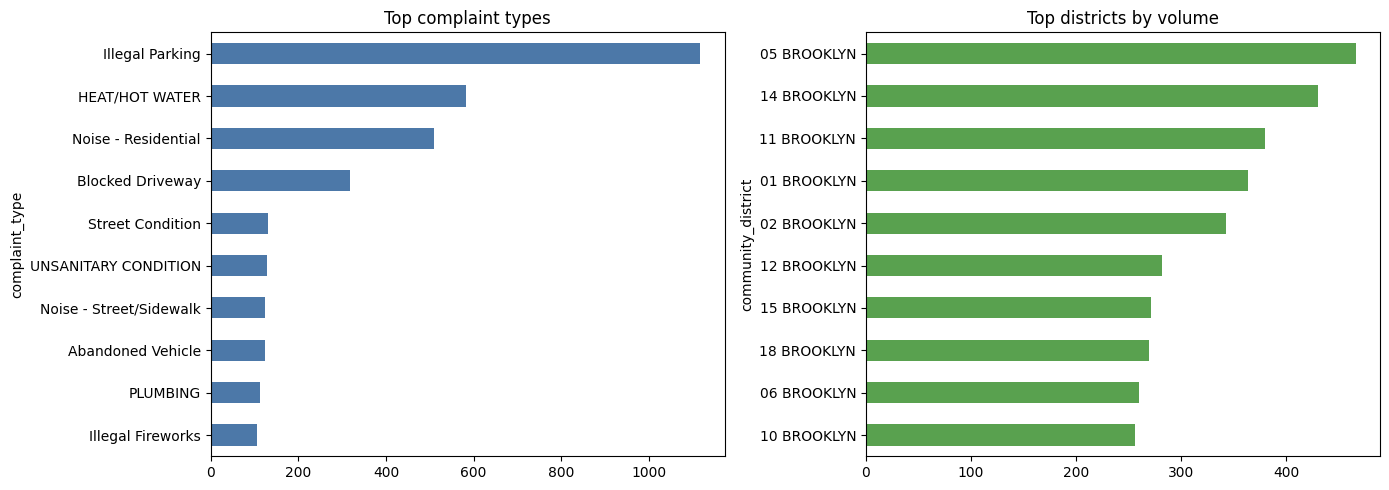

In [7]:
complaint_type_counts = Counter(record.complaint_type for record in records)
district_counts = Counter(record.community_district for record in records)

complaint_type_df = nyc311.records_to_dataframe(records)[["complaint_type"]]
complaint_type_df = (
    complaint_type_df["complaint_type"]
    .value_counts()
    .rename_axis("complaint_type")
    .reset_index(name="count")
)
district_df = (
    nyc311.records_to_dataframe(records)["community_district"]
    .value_counts()
    .rename_axis("community_district")
    .reset_index(name="count")
)

display(complaint_type_df.head(10))
display(district_df.head(10))

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    complaint_type_df.head(10).sort_values("count").plot.barh(
        x="complaint_type",
        y="count",
        ax=axes[0],
        color="#4C78A8",
        legend=False,
        title="Top complaint types",
    )
    district_df.head(10).sort_values("count").plot.barh(
        x="community_district",
        y="count",
        ax=axes[1],
        color="#59A14F",
        legend=False,
        title="Top districts by volume",
    )
    plt.tight_layout()
    plt.show()
except ImportError:
    complaint_type_counts.most_common(10), district_counts.most_common(10)

,geography,geography_value,complaint_type,total_request_count,resolved_request_count,unresolved_request_count,unresolved_share,resolution_rate
0,borough,BROOKLYN,Construction Lead Dust,2,0,2,1.000000,0.000000
1,borough,BROOKLYN,Lot Condition,2,0,2,1.000000,0.000000
2,borough,BROOKLYN,For Hire Vehicle Report,1,0,1,1.000000,0.000000
3,borough,BROOKLYN,Tobacco or Non-Tobacco Sale,1,0,1,1.000000,0.000000
4,borough,BROOKLYN,Unleashed Dog,1,0,1,1.000000,0.000000
5,borough,BROOKLYN,Water Quality,1,0,1,1.000000,0.000000
6,borough,BROOKLYN,Food Poisoning,3,1,2,0.666667,0.333333
7,borough,BROOKLYN,Wood Pile Remaining,2,1,1,0.500000,0.500000
8,borough,BROOKLYN,Graffiti,55,37,18,0.327273,0.672727
9,borough,BROOKLYN,Overgrown Tree/Branches,12,9,3,0.250000,0.750000


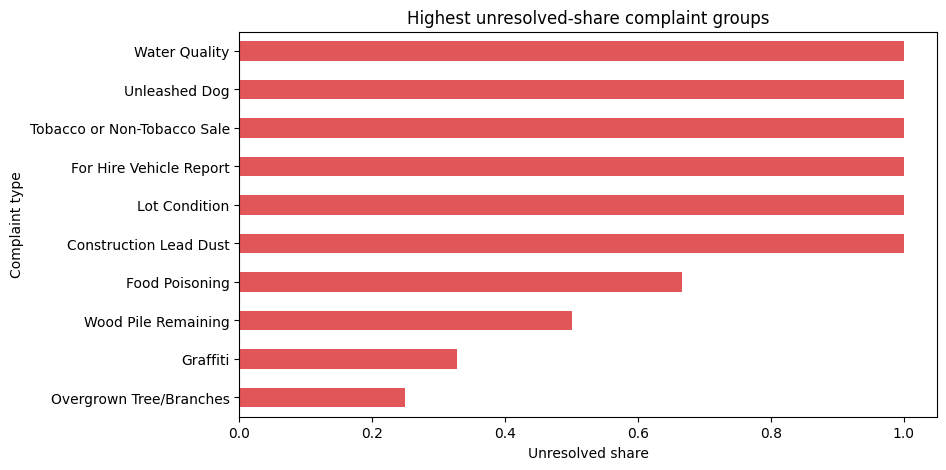

In [8]:
resolution_records = [
    record for record in records if record.resolution_description is not None
]
resolution_summaries = nyc311.analyze_resolution_gaps(records, resolution_records)
resolution_df = nyc311.gaps_to_dataframe(resolution_summaries)
display(resolution_df.head(10))

try:
    import matplotlib.pyplot as plt

    plot_df = resolution_df.head(10).sort_values("unresolved_share")
    ax = plot_df.plot.barh(
        x="complaint_type",
        y="unresolved_share",
        figsize=(9, 5),
        color="#E15759",
        legend=False,
        title="Highest unresolved-share complaint groups",
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Unresolved share")
    ax.set_ylabel("Complaint type")
    plt.show()
except ImportError:
    display(resolution_df[["complaint_type", "unresolved_share"]].head(10))

,geography,geography_value,complaint_type,topic,complaint_count,geography_total_count,share_of_geography,topic_rank,is_dominant_topic
8,community_district,04 BROOKLYN,Noise - Residential,party_music,30,33,0.909091,1,True
47,community_district,18 BROOKLYN,Noise - Residential,party_music,15,18,0.833333,1,True
14,community_district,06 BROOKLYN,Noise - Residential,party_music,10,12,0.833333,1,True
5,community_district,03 BROOKLYN,Noise - Residential,party_music,34,43,0.790698,1,True
17,community_district,07 BROOKLYN,Noise - Residential,party_music,9,12,0.750000,1,True
25,community_district,10 BROOKLYN,Noise - Residential,party_music,18,25,0.720000,1,True
42,community_district,16 BROOKLYN,Noise - Residential,party_music,10,14,0.714286,1,True
3,community_district,02 BROOKLYN,Noise - Residential,banging,22,33,0.666667,1,True
28,community_district,11 BROOKLYN,Noise - Residential,party_music,31,47,0.659574,1,True
39,community_district,15 BROOKLYN,Noise - Residential,banging,15,24,0.625000,1,True


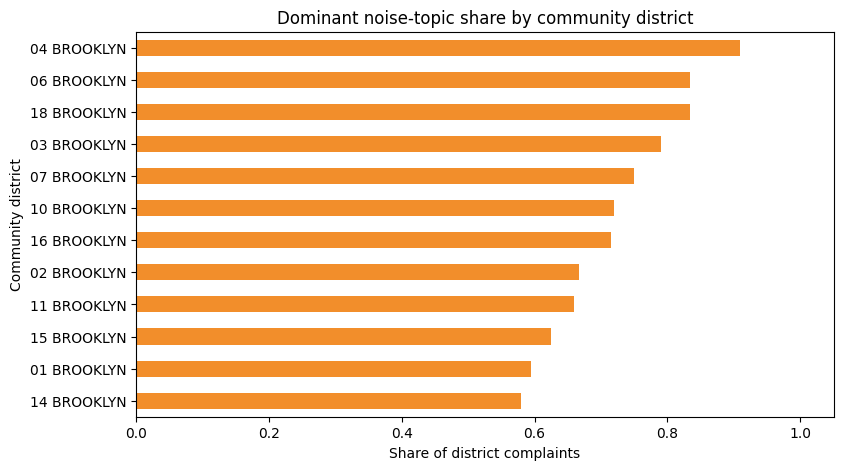

In [9]:
noise_records = [
    record for record in records if record.complaint_type == "Noise - Residential"
]
assignments = nyc311.extract_topics(
    noise_records,
    nyc311.TopicQuery("Noise - Residential"),
)
summaries = nyc311.aggregate_by_geography(assignments, geography="community_district")
summaries_df = nyc311.summaries_to_dataframe(summaries)
dominant_noise_df = summaries_df[summaries_df["is_dominant_topic"]].sort_values(
    "share_of_geography",
    ascending=False,
)

display(dominant_noise_df.head(10))

try:
    import matplotlib.pyplot as plt

    ax = (
        dominant_noise_df.head(12)
        .sort_values("share_of_geography")
        .plot.barh(
            x="geography_value",
            y="share_of_geography",
            figsize=(9, 5),
            color="#F28E2B",
            legend=False,
            title="Dominant noise-topic share by community district",
        )
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Share of district complaints")
    ax.set_ylabel("Community district")
    plt.show()
except ImportError:
    display(
        dominant_noise_df[["geography_value", "topic", "share_of_geography"]].head(10)
    )

In [10]:
# Optional: export later if you decide this live slice is worth keeping.
# The notebook itself stays notebook-native and avoids active file writes.
#
# For repeatable bulk downloads or script-driven workflows, see
# examples/scripts/.
#
# nyc311.export_service_requests_csv(
#     records,
#     nyc311.ExportTarget("csv", "brooklyn-large-sample.csv"),
# )
#
# nyc311.export_topic_table(
#     summaries,
#     nyc311.ExportTarget("csv", "brooklyn-noise-community-districts.csv"),
# )